# R02 — Gun Accuracy

**Goal:** Measure how accurately our robot hits opponents.

**Hit rate** = bullets that hit ÷ bullets fired. A random shooter gets ~5–10%.
Competitive robots aim for 12–20%. If our hit rate is low, our gun (aiming)
system needs improvement.

In [1]:
import sys; sys.path.insert(0, '..')
from retrospective._retro_helpers import load_local_scores, add_opponent_names
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

scores = add_opponent_names(load_local_scores())
print(f'Loaded {len(scores):,} score rows')

Indexed 60 ticks.csv files across 7 distinct robots from 1 root(s).
Selected 7 robots × ~100 battles = 60 (battle, robot) pairs to load.
Loaded 60 scores.csv files → 2,100 rows × 17 cols, 7 robots (~0.4 MB)
Loaded 1,050 score rows


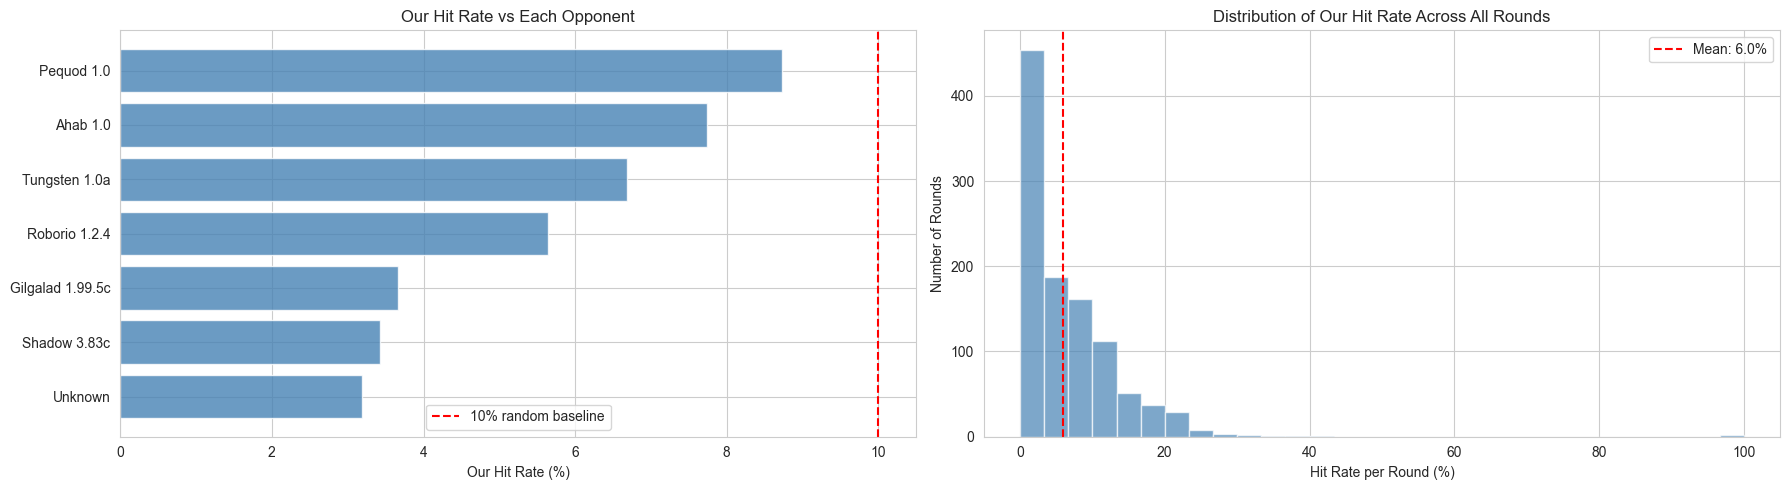


Overall mean hit rate: 6.0%
Best matchup:  Pequod 1.0 (8.7%)
Worst matchup: Unknown (3.2%)


In [2]:
# Our hit rate per opponent
opp_hr = scores.groupby('opponent_name')['our_hit_rate'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(opp_hr)*0.5)))

ax = axes[0]
ax.barh(opp_hr.index, opp_hr.values * 100, color='steelblue', alpha=0.8)
ax.set_xlabel('Our Hit Rate (%)')
ax.set_title('Our Hit Rate vs Each Opponent')
ax.axvline(x=10, color='red', linestyle='--', label='10% random baseline')
ax.legend()

ax = axes[1]
ax.hist(scores['our_hit_rate'].dropna() * 100, bins=30, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_xlabel('Hit Rate per Round (%)')
ax.set_ylabel('Number of Rounds')
ax.set_title('Distribution of Our Hit Rate Across All Rounds')
mean_hr = scores['our_hit_rate'].mean()*100
ax.axvline(x=mean_hr, color='red', linestyle='--', label=f'Mean: {mean_hr:.1f}%')
ax.legend()

plt.tight_layout()
plt.show()

print(f'\nOverall mean hit rate: {mean_hr:.1f}%')
print(f'Best matchup:  {opp_hr.index[-1]} ({opp_hr.iloc[-1]*100:.1f}%)')
print(f'Worst matchup: {opp_hr.index[0]} ({opp_hr.iloc[0]*100:.1f}%)')